## Packages and Set Up

In [1]:
# Core libraries
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# Model
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance
# Statistics
from scipy import stats
from scipy.stats import gaussian_kde
# Optimization
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
# Utilities
import subprocess
import re

c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = 'cuda' if subprocess.run(
    ['nvidia-smi'], capture_output=True
).returncode == 0 else 'cpu'
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
import os

DRIVE_ROOT = r"C:\Users\Claudio\OneDrive\Documents\Data Science Masters\DS 5003 - Healthcare Data Science\Project\Updated Plan 1K Non-Covid" + "\\"
assert os.path.exists(DRIVE_ROOT + "1kdata_v2.csv"), "CSV not found — check your path!"
print(f"Drive root: {DRIVE_ROOT}")

Drive root: C:\Users\Claudio\OneDrive\Documents\Data Science Masters\DS 5003 - Healthcare Data Science\Project\Updated Plan 1K Non-Covid\


## Loading Data & Preprocessing
V4 data: 1180 contiions + procedures top 20 + medications top 20

In [5]:
mydatav4 = pd.read_csv(DRIVE_ROOT + '1kdata_v2.csv')
def clean_columns(df):
    df = df.copy()
    df.columns = [
        re.sub("_+", "_", re.sub(r"[^A-Za-z0-9_]", "_", col)).strip("_")
        for col in df.columns
    ]
    return df

mydata = clean_columns(mydatav4)

C:\Users\Claudio\AppData\Local\Temp\ipykernel_4544\2810326404.py:1: DtypeWarning: Columns (0: MARITAL) have mixed types. Specify dtype option on import or set low_memory=False.
  mydatav4 = pd.read_csv(DRIVE_ROOT + '1kdata_v2.csv')


In [6]:
drop_cols = [
        "ENCOUNTER_ID", "PATIENT",
        "REASONDESCRIPTION", "HOSPITAL_CITY"
    ]

mydata['total_encounter_cost'] = mydata['total_encounter_cost'].round(2)
mydata = mydata.drop(columns=[c for c in drop_cols if c in mydata.columns], errors="ignore")

X = mydata.drop(columns=['total_encounter_cost'])
y = np.log1p(mydata['total_encounter_cost'])

print(f" shape: X={X.shape}, y={y.shape}")

 shape: X=(61459, 235), y=(61459,)


In [7]:
cat_cols = ['ENCOUNTERCLASS', 'GENDER', 'RACE', 'MARITAL', 'INSURANCE_PROVIDER']

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

assert len(X.select_dtypes(include='object').columns) == 0, "X still has object columns"
print("All clear")

All clear


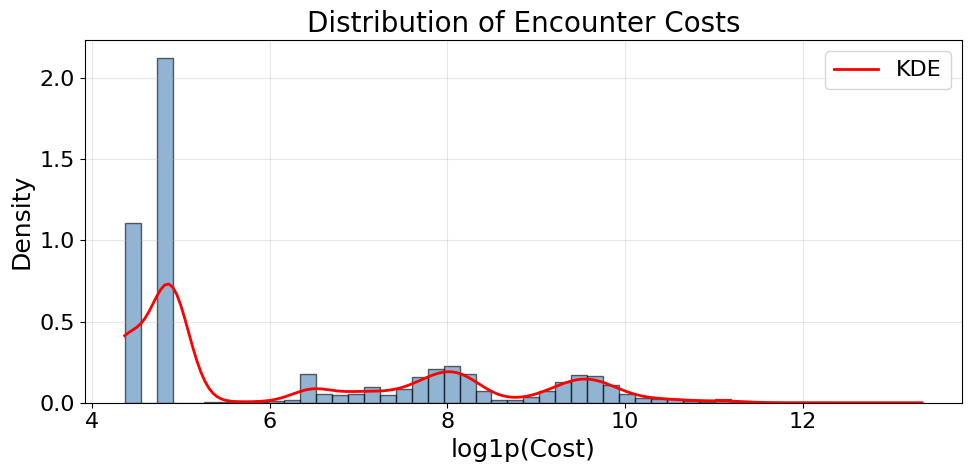

In [8]:
raw_cost = mydata['total_encounter_cost'].values
log_cost = np.log1p(raw_cost)

# Set font sizes
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['legend.fontsize'] = 16

fig, ax = plt.subplots(figsize=(10, 5))

# Histogram
ax.hist(log_cost, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor='black')

# KDE curve
kde = gaussian_kde(log_cost)
x_range = np.linspace(log_cost.min(), log_cost.max(), 200)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

ax.set_xlabel('log1p(Cost)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Encounter Costs')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('kde_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=5003
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=5003
)

# ── Sanity checks ───
for name, X_train, X_val, X_test, y_train, y_val, y_test in [
    ("Data", X_train, X_val, X_test, y_train, y_val, y_test),
]:
    total = len(X_train) + len(X_val) + len(X_test)
    print(f"\n── {name} ──")
    print(f"Train: {len(X_train)} ({len(X_train)/total:.1%})")
    print(f"Val:   {len(X_val)}   ({len(X_val)/total:.1%})")
    print(f"Test:  {len(X_test)}  ({len(X_test)/total:.1%})")
    print(f"y_train mean: {y_train.mean():.3f}")
    print(f"y_val mean:   {y_val.mean():.3f}")
    print(f"y_test mean:  {y_test.mean():.3f}")


── Data ──
Train: 43045 (70.0%)
Val:   9195   (15.0%)
Test:  9219  (15.0%)
y_train mean: 6.208
y_val mean:   6.243
y_test mean:  6.210


## XGBoost Model

In [10]:
class XGBoostModel:
    """
    XGBoost regressor for healthcare encounter cost prediction.
    - Imputes separately from model (avoids pipeline feature-name issues)
    - Bayesian hyperparameter search via Optuna
    - Learning curve, gain-based feature importance, residual plots
    """

    def __init__(self, name, X_train, X_val, X_test, y_train, y_val, y_test):
        self.name        = name
        self.X_train     = X_train
        self.X_val       = X_val
        self.X_test      = X_test
        self.y_train     = y_train
        self.y_val       = y_val
        self.y_test      = y_test
        self.best_model  = None
        self.best_params = {}
        self.cv_mae      = None
        self.results     = {}
        self._imputer    = None

    # ── Impute ───────────────────────────────────────────────────────────────
    def _fit_imputer(self):
        self._imputer = SimpleImputer(strategy='median')
        X_train_imp = pd.DataFrame(
            self._imputer.fit_transform(self.X_train),
            columns=self.X_train.columns
        )
        X_val_imp = pd.DataFrame(
            self._imputer.transform(self.X_val),
            columns=self.X_val.columns
        )
        X_test_imp = pd.DataFrame(
            self._imputer.transform(self.X_test),
            columns=self.X_test.columns
        )
        return X_train_imp, X_val_imp, X_test_imp

    def _impute(self, X):
        return pd.DataFrame(
            self._imputer.transform(X),
            columns=X.columns
        )

    # ── Tune ─────────────────────────────────────────────────────────────────
    def tune(self, n_trials=50):
        print(f"\n{'='*50}\nTuning: {self.name} (Optuna, {n_trials} trials)\n{'='*50}")

        X_train_imp, X_val_imp, _ = self._fit_imputer()

        def objective(trial):
            params = {
                'max_depth':        trial.suggest_int  ('max_depth',   3, 10),
                'learning_rate':    trial.suggest_float('lr',          0.01, 0.3,  log=True),
                'subsample':        trial.suggest_float('subsample',   0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample',   0.6, 1.0),
                'min_child_weight': trial.suggest_int  ('min_child_w', 1,   20),
                'reg_alpha':        trial.suggest_float('alpha',       1e-8, 10.0, log=True),
                'reg_lambda':       trial.suggest_float('lambda',      1e-8, 10.0, log=True),
            }
            model = XGBRegressor(
                objective             = 'reg:squarederror',
                tree_method           = 'hist',
                device                = DEVICE,
                n_estimators          = 1000,
                early_stopping_rounds = 50,
                eval_metric           = ['rmse', 'mae'],
                random_state          = 5003,
                **params
            )
            model.fit(
                X_train_imp, self.y_train,
                eval_set=[(X_val_imp, self.y_val)],
                verbose=False
            )
            return mean_absolute_error(self.y_val, model.predict(X_val_imp))

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

        self.best_params = study.best_params
        self.cv_mae      = study.best_value

        # ── Final refit with best params ──
        self.best_model = XGBRegressor(
            objective             = 'reg:squarederror',
            tree_method           = 'hist',
            device                = DEVICE,
            n_estimators          = 1000,
            early_stopping_rounds = 50,
            eval_metric           = ['rmse', 'mae'],
            random_state          = 5003,
            **study.best_params
        )
        self.best_model.fit(
            X_train_imp, self.y_train,
            eval_set=[(X_val_imp, self.y_val)],
            verbose=False
        )
        print(f"Best val MAE: {self.cv_mae:.4f}")
        return self

    # ── Evaluate ─────────────────────────────────────────────────────────────
    def evaluate(self, on='val'):
        X = self._impute(self.X_val) if on == 'val' else self._impute(self.X_test)
        y = self.y_val               if on == 'val' else self.y_test

        y_pred_log     = self.best_model.predict(X)
        y_pred_dollars = np.expm1(y_pred_log)
        y_true_dollars = np.expm1(y)

        threshold = np.percentile(y_true_dollars, 90)
        mask      = y_true_dollars >= threshold

        self.results[on] = {
            'mae_log':      mean_absolute_error(y, y_pred_log),
            'r2_log':       r2_score(y, y_pred_log),
            'mae_dollars':  mean_absolute_error(y_true_dollars, y_pred_dollars),
            'rmse_dollars': np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars)),
            'r2_dollars':   r2_score(y_true_dollars, y_pred_dollars),
            'mae_p90':      mean_absolute_error(y_true_dollars[mask], y_pred_dollars[mask]),
        }
        r = self.results[on]
        print(f"\n── {self.name} | {on.upper()} ──")
        print(f"  CV MAE (log):        {self.cv_mae:.4f}")
        print(f"  MAE  (log scale):    {r['mae_log']:.4f}")
        print(f"  R²   (log scale):    {r['r2_log']:.4f}")
        print(f"  MAE  (dollars):      ${r['mae_dollars']:>12,.2f}")
        print(f"  RMSE (dollars):      ${r['rmse_dollars']:>12,.2f}")
        print(f"  R²   (dollar scale): {r['r2_dollars']:.4f}")
        print(f"  MAE  (top-10% cost): ${r['mae_p90']:>12,.2f}")
        print(f"  Best params: {self.best_params}")
        return self

    # ── Residual plot ─────────────────────────────────────────────────────────
    def residual_plot(self, on='val'):
        X = self._impute(self.X_val) if on == 'val' else self._impute(self.X_test)
        y = self.y_val               if on == 'val' else self.y_test

        y_pred_log     = self.best_model.predict(X)
        y_pred_dollars = np.expm1(y_pred_log)
        y_true_dollars = np.expm1(y)
        residuals      = y_true_dollars - y_pred_dollars

        fig = plt.figure(figsize=(14, 4))
        gs  = gridspec.GridSpec(1, 3, figure=fig)

        ax1 = fig.add_subplot(gs[0])
        ax1.scatter(y_pred_dollars, residuals, alpha=0.25, s=8, color='steelblue')
        ax1.axhline(0, color='red', linewidth=1)
        ax1.set_xlabel('Predicted ($)')
        ax1.set_ylabel('Residual ($)')
        ax1.set_title(f'{self.name} — Residuals vs Predicted')

        ax2 = fig.add_subplot(gs[1])
        ax2.hist(residuals, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
        ax2.axvline(0, color='red', linewidth=1)
        ax2.set_xlabel('Residual ($)')
        ax2.set_ylabel('Count')
        ax2.set_title('Residual Distribution')

        ax3 = fig.add_subplot(gs[2])
        ax3.scatter(y_true_dollars, y_pred_dollars, alpha=0.25, s=8, color='darkorange')
        lims = [min(y_true_dollars.min(), y_pred_dollars.min()),
                max(y_true_dollars.max(), y_pred_dollars.max())]
        ax3.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
        ax3.set_xlabel('Actual ($)')
        ax3.set_ylabel('Predicted ($)')
        ax3.set_title('Actual vs Predicted')
        ax3.legend(fontsize=8)

        plt.suptitle(f'{self.name} | {on.upper()} set', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
        return self

    # ── Val vs Test comparison ────────────────────────────────────────────────
    def compare_splits(self):
        if not ('val' in self.results and 'test' in self.results):
            print("Run evaluate(on='val') and evaluate(on='test') first.")
            return self

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        splits = ['val', 'test']
        colors = ['steelblue', 'darkorange']

        dollar_metrics = ['mae_dollars', 'rmse_dollars']
        x = np.arange(len(dollar_metrics))
        for i, (split, color) in enumerate(zip(splits, colors)):
            ax1.bar(x + i*0.35, [self.results[split][m] for m in dollar_metrics],
                    0.35, label=split.capitalize(), color=color)
        ax1.set_xticks(x + 0.175)
        ax1.set_xticklabels(['MAE ($)', 'RMSE ($)'])
        ax1.set_title(f'{self.name} — Dollar Metrics')
        ax1.legend()

        r2_vals = [self.results[s]['r2_dollars'] for s in splits]
        ax2.bar(splits, r2_vals, color=colors)
        ax2.set_ylim(0, 1)
        ax2.set_title(f'{self.name} — R² (dollar scale)')
        for i, v in enumerate(r2_vals):
            ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

        plt.tight_layout()
        plt.show()
        return self

    # ── XGBoost-only: learning curve ─────────────────────────────────────────
    def plot_learning_curve(self):
        evals  = self.best_model.evals_result()
        rounds = range(len(evals['validation_0']['rmse']))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(rounds, evals['validation_0']['rmse'], color='steelblue')
        ax1.set_xlabel('Boosting Round')
        ax1.set_ylabel('RMSE (log scale)')
        ax1.set_title(f'{self.name} — Val RMSE per Round')

        ax2.plot(rounds, evals['validation_0']['mae'], color='darkorange')
        ax2.set_xlabel('Boosting Round')
        ax2.set_ylabel('MAE (log scale)')
        ax2.set_title(f'{self.name} — Val MAE per Round')

        plt.suptitle(f'{self.name} — Learning Curve', fontsize=12)
        plt.tight_layout()
        plt.show()
        return self

    # ── XGBoost-only: feature importance ─────────────────────────────────────
    def feature_importance(self, top_n=20, importance_type='gain'):
        booster = self.best_model.get_booster()
        booster.feature_names = list(self.X_train.columns)

        importances = (
            pd.Series(booster.get_score(importance_type=importance_type))
            .sort_values(ascending=False)
            .head(top_n)
        )
        importances.plot(kind='barh', figsize=(8, 6), color='steelblue',
                         title=f"{self.name} — Top {top_n} Features ({importance_type})")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        return self

## Random Forest Model

In [11]:
class RFModel:
    """
    Random Forest regressor for healthcare encounter cost prediction.
    - sklearn Pipeline with median imputation
    - RandomizedSearchCV hyperparameter tuning
    - OOB score, permutation importance, residual plots
    """

    def __init__(self, name, X_train, X_val, X_test, y_train, y_val, y_test):
        self.name        = name
        self.X_train     = X_train
        self.X_val       = X_val
        self.X_test      = X_test
        self.y_train     = y_train
        self.y_val       = y_val
        self.y_test      = y_test
        self.best_model  = None
        self.best_params = {}
        self.cv_mae      = None
        self.results     = {}

    # ── Pipeline ─────────────────────────────────────────────────────────────
    def _build_pipeline(self):
        return Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('rf', RandomForestRegressor(
                random_state = 5003,
                oob_score    = True,
                n_jobs       = -1
            ))
        ])

    # ── Tune ─────────────────────────────────────────────────────────────────
    def tune(self, n_iter=20):
        print(f"\n{'='*50}\nTuning: {self.name} (RandomizedSearchCV, {n_iter} iters)\n{'='*50}")

        param_grid = {
            'rf__n_estimators':      [200, 300, 500],
            'rf__max_depth':         [10, 20, 30, None],
            'rf__min_samples_split': [2, 5, 10],
            'rf__min_samples_leaf':  [1, 2, 4],
            'rf__max_features':      ['sqrt', 0.3, 0.5],
            'rf__max_samples':       [0.7, 0.8, 1.0],
        }
        random_cv = RandomizedSearchCV(
            self._build_pipeline(),
            param_grid,
            n_iter            = n_iter,
            cv                = 3,
            scoring           = 'neg_mean_absolute_error',
            n_jobs            = -1,
            random_state      = 5003,
            return_train_score = True,
            verbose           = 1
        )
        random_cv.fit(self.X_train, self.y_train)

        self.best_model  = random_cv.best_estimator_
        self.best_params = random_cv.best_params_
        self.cv_mae      = -random_cv.best_score_
        return self

    # ── Evaluate ─────────────────────────────────────────────────────────────
    def evaluate(self, on='val'):
        X = self.X_val if on == 'val' else self.X_test
        y = self.y_val if on == 'val' else self.y_test

        y_pred_log     = self.best_model.predict(X)
        y_pred_dollars = np.expm1(y_pred_log)
        y_true_dollars = np.expm1(y)

        threshold = np.percentile(y_true_dollars, 90)
        mask      = y_true_dollars >= threshold

        self.results[on] = {
            'mae_log':      mean_absolute_error(y, y_pred_log),
            'r2_log':       r2_score(y, y_pred_log),
            'mae_dollars':  mean_absolute_error(y_true_dollars, y_pred_dollars),
            'rmse_dollars': np.sqrt(mean_squared_error(y_true_dollars, y_pred_dollars)),
            'r2_dollars':   r2_score(y_true_dollars, y_pred_dollars),
            'mae_p90':      mean_absolute_error(y_true_dollars[mask], y_pred_dollars[mask]),
        }
        r = self.results[on]
        print(f"\n── {self.name} | {on.upper()} ──")
        print(f"  CV MAE (log):        {self.cv_mae:.4f}")
        print(f"  MAE  (log scale):    {r['mae_log']:.4f}")
        print(f"  R²   (log scale):    {r['r2_log']:.4f}")
        print(f"  MAE  (dollars):      ${r['mae_dollars']:>12,.2f}")
        print(f"  RMSE (dollars):      ${r['rmse_dollars']:>12,.2f}")
        print(f"  R²   (dollar scale): {r['r2_dollars']:.4f}")
        print(f"  MAE  (top-10% cost): ${r['mae_p90']:>12,.2f}")
        print(f"  Best params: {self.best_params}")
        return self

    # ── Residual plot ─────────────────────────────────────────────────────────
    def residual_plot(self, on='val'):
        X = self.X_val if on == 'val' else self.X_test
        y = self.y_val if on == 'val' else self.y_test

        y_pred_log     = self.best_model.predict(X)
        y_pred_dollars = np.expm1(y_pred_log)
        y_true_dollars = np.expm1(y)
        residuals      = y_true_dollars - y_pred_dollars

        fig = plt.figure(figsize=(14, 4))
        gs  = gridspec.GridSpec(1, 3, figure=fig)

        ax1 = fig.add_subplot(gs[0])
        ax1.scatter(y_pred_dollars, residuals, alpha=0.25, s=8, color='darkorange')
        ax1.axhline(0, color='red', linewidth=1)
        ax1.set_xlabel('Predicted ($)')
        ax1.set_ylabel('Residual ($)')
        ax1.set_title(f'{self.name} — Residuals vs Predicted')

        ax2 = fig.add_subplot(gs[1])
        ax2.hist(residuals, bins=60, color='darkorange', edgecolor='white', linewidth=0.3)
        ax2.axvline(0, color='red', linewidth=1)
        ax2.set_xlabel('Residual ($)')
        ax2.set_ylabel('Count')
        ax2.set_title('Residual Distribution')

        ax3 = fig.add_subplot(gs[2])
        ax3.scatter(y_true_dollars, y_pred_dollars, alpha=0.25, s=8, color='steelblue')
        lims = [min(y_true_dollars.min(), y_pred_dollars.min()),
                max(y_true_dollars.max(), y_pred_dollars.max())]
        ax3.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
        ax3.set_xlabel('Actual ($)')
        ax3.set_ylabel('Predicted ($)')
        ax3.set_title('Actual vs Predicted')
        ax3.legend(fontsize=8)

        plt.suptitle(f'{self.name} | {on.upper()} set', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
        return self

    # ── Val vs Test comparison ────────────────────────────────────────────────
    def compare_splits(self):
        if not ('val' in self.results and 'test' in self.results):
            print("Run evaluate(on='val') and evaluate(on='test') first.")
            return self

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        splits = ['val', 'test']
        colors = ['steelblue', 'darkorange']

        dollar_metrics = ['mae_dollars', 'rmse_dollars']
        x = np.arange(len(dollar_metrics))
        for i, (split, color) in enumerate(zip(splits, colors)):
            ax1.bar(x + i*0.35, [self.results[split][m] for m in dollar_metrics],
                    0.35, label=split.capitalize(), color=color)
        ax1.set_xticks(x + 0.175)
        ax1.set_xticklabels(['MAE ($)', 'RMSE ($)'])
        ax1.set_title(f'{self.name} — Dollar Metrics')
        ax1.legend()

        r2_vals = [self.results[s]['r2_dollars'] for s in splits]
        ax2.bar(splits, r2_vals, color=colors)
        ax2.set_ylim(0, 1)
        ax2.set_title(f'{self.name} — R² (dollar scale)')
        for i, v in enumerate(r2_vals):
            ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

        plt.tight_layout()
        plt.show()
        return self

    # ── RF-only: OOB score ────────────────────────────────────────────────────
    def oob_score(self):
        rf = self.best_model.named_steps['rf']
        print(f"\n{self.name} — OOB R²: {rf.oob_score_:.4f}")
        return self

    # ── RF-only: permutation importance ──────────────────────────────────────
    def feature_importance(self, top_n=20):
        result = permutation_importance(
            self.best_model, self.X_val, self.y_val,
            n_repeats    = 10,
            random_state = 5003,
            n_jobs       = -1
        )
        importances = (
            pd.Series(result.importances_mean, index=self.X_train.columns)
            .sort_values(ascending=False)
            .head(top_n)
        )
        errors = pd.Series(
            result.importances_std, index=self.X_train.columns
        ).loc[importances.index]

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(importances.index, importances.values,
                xerr=errors.values, color='darkorange',
                ecolor='gray', capsize=3)
        ax.invert_yaxis()
        ax.set_title(f'{self.name} — Top {top_n} Features (Permutation Importance)')
        plt.tight_layout()
        plt.show()
        return self

    # ── RF-only: OOB error vs n_estimators ───────────────────────────────────
    def plot_learning_curve(self, sample_size=50000):
        best_params = {
            k.replace('rf__', ''): v
            for k, v in self.best_params.items()
            if k != 'rf__n_estimators'
        }
        # subsample for speed
        idx      = np.random.choice(len(self.X_train), size=min(sample_size, len(self.X_train)), replace=False)
        X_sample = self.X_train.iloc[idx]
        y_sample = self.y_train.iloc[idx]

        tree_counts = range(10, 310, 10)
        oob_errors  = []
        for n in tree_counts:
            rf = RandomForestRegressor(
                **best_params,
                n_estimators = n,
                oob_score    = True,
                random_state = 5003,
                n_jobs       = -1
            )
            rf.fit(X_sample, y_sample)
            oob_errors.append(1 - rf.oob_score_)

        plt.figure(figsize=(8, 4))
        plt.plot(tree_counts, oob_errors, color='darkorange')
        plt.xlabel('Number of Trees')
        plt.ylabel('OOB Error (1 - R²)')
        plt.title(f'{self.name} — OOB Error vs Number of Trees')
        plt.tight_layout()
        plt.show()
        return self

## Fitting Data, Training Model


Tuning: XGBoost (Optuna, 50 trials)


  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:751: UserWarning: [20:44:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
Best trial: 23. Best value: 0.0865421: 100%|██████████| 50/50 [03:29<00:00,  4.19s/it]
c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:385: UserWarning: [20:48:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "colsample", "lr", "min_child_w" } are not used.

  self.s

Best val MAE: 0.0865

── XGBoost | VAL ──
  CV MAE (log):        0.0865
  MAE  (log scale):    0.0927
  R²   (log scale):    0.9900
  MAE  (dollars):      $      722.57
  RMSE (dollars):      $    5,075.19
  R²   (dollar scale): 0.7349
  MAE  (top-10% cost): $    4,947.28
  Best params: {'max_depth': 10, 'lr': 0.016883347370282693, 'subsample': 0.903805340081769, 'colsample': 0.9101285031171146, 'min_child_w': 1, 'alpha': 1.3675169251765082e-07, 'lambda': 0.13244856459145535}

── XGBoost | TEST ──
  CV MAE (log):        0.0865
  MAE  (log scale):    0.0926
  R²   (log scale):    0.9887
  MAE  (dollars):      $      678.39
  RMSE (dollars):      $    3,149.39
  R²   (dollar scale): 0.9045
  MAE  (top-10% cost): $    4,429.35
  Best params: {'max_depth': 10, 'lr': 0.016883347370282693, 'subsample': 0.903805340081769, 'colsample': 0.9101285031171146, 'min_child_w': 1, 'alpha': 1.3675169251765082e-07, 'lambda': 0.13244856459145535}


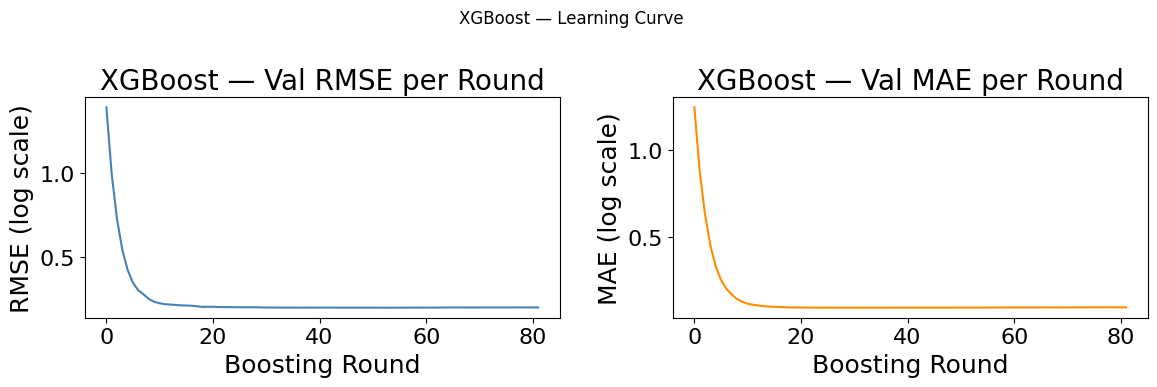

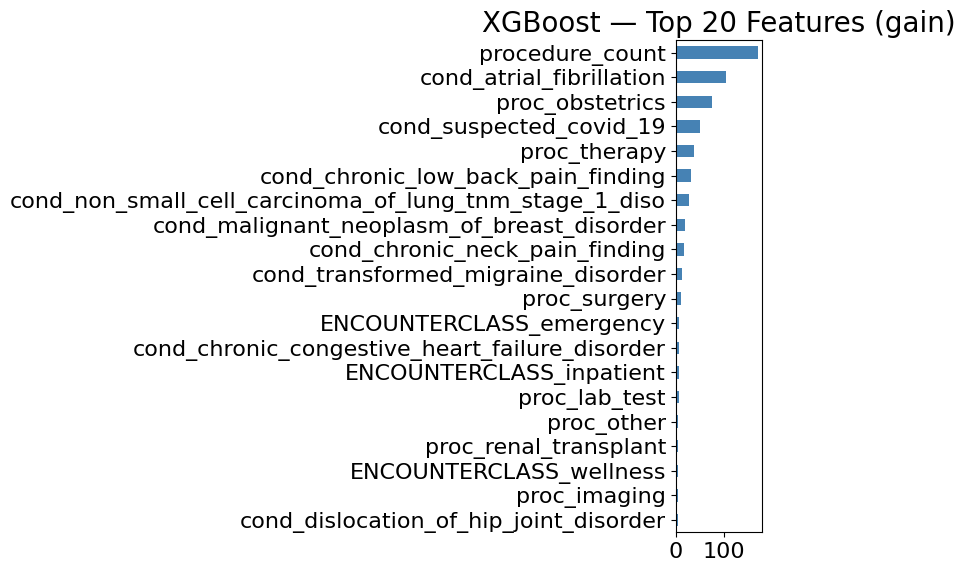

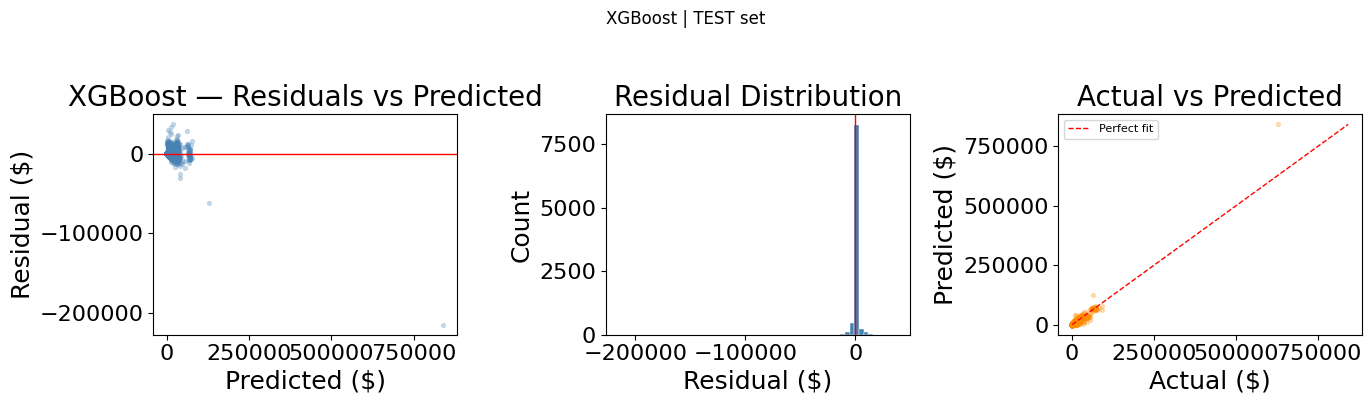

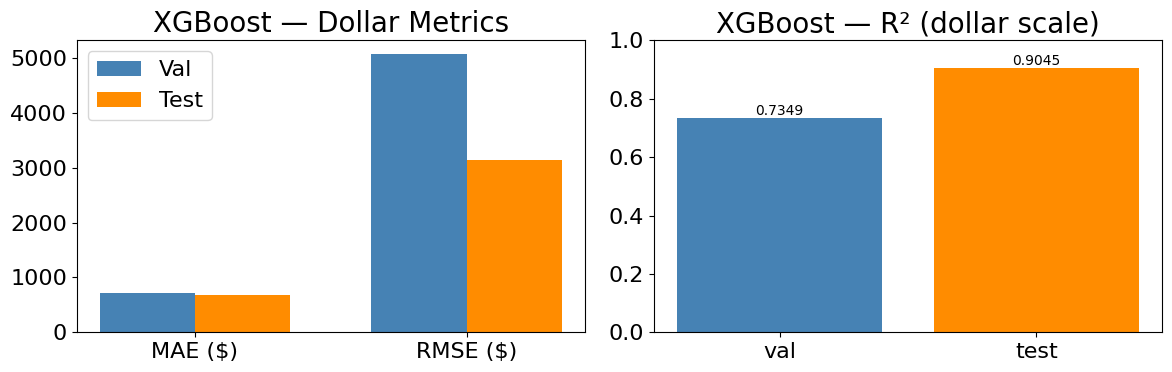

In [12]:
## XGBOOST

xgb = (
  XGBoostModel("XGBoost", X_train, X_val, X_test, y_train, y_val, y_test)
  .tune(n_trials=50)
  .evaluate(on='val')
  .evaluate(on='test')
  .plot_learning_curve()
  .feature_importance(importance_type='gain')
  .residual_plot(on='test')
  .compare_splits()
)


Tuning: Random Forest (RandomizedSearchCV, 20 iters)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

── Random Forest | VAL ──
  CV MAE (log):        0.0904
  MAE  (log scale):    0.0858
  R²   (log scale):    0.9905
  MAE  (dollars):      $      720.23
  RMSE (dollars):      $    5,407.94
  R²   (dollar scale): 0.6990
  MAE  (top-10% cost): $    5,089.86
  Best params: {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_samples': 0.7, 'rf__max_features': 0.5, 'rf__max_depth': None}

── Random Forest | TEST ──
  CV MAE (log):        0.0904
  MAE  (log scale):    0.0837
  R²   (log scale):    0.9899
  MAE  (dollars):      $      714.20
  RMSE (dollars):      $    6,545.37
  R²   (dollar scale): 0.5874
  MAE  (top-10% cost): $    4,982.94
  Best params: {'rf__n_estimators': 300, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_samples': 0.7, 'rf__max_features': 0.5, 'rf__max_depth': None}

Random Forest — OOB R²: 0.9897


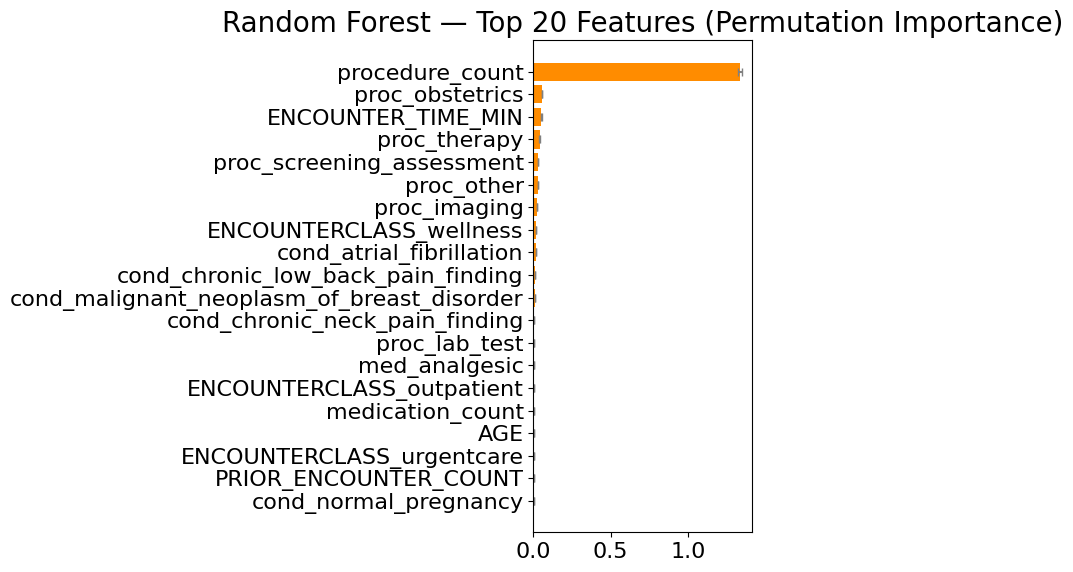

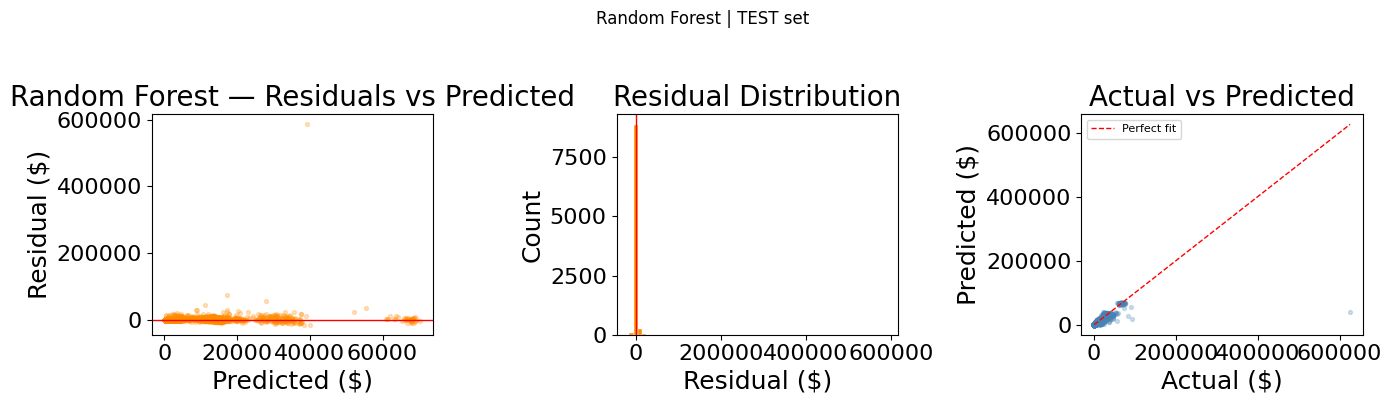

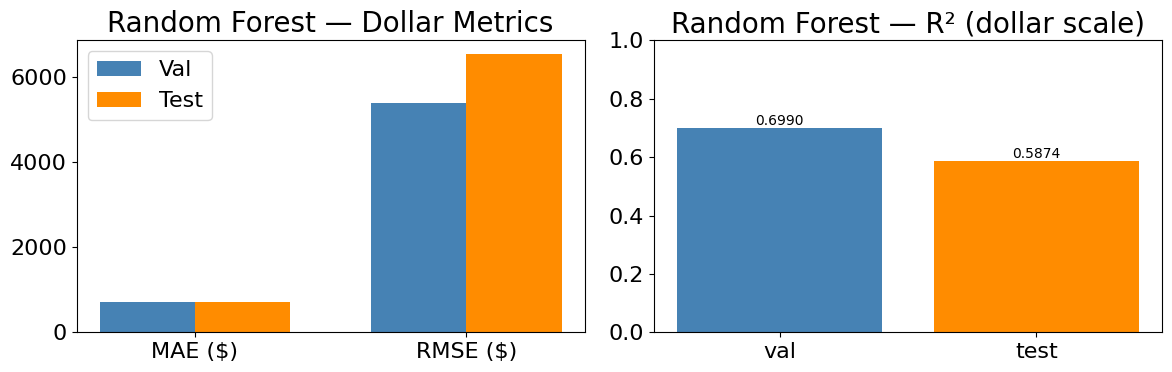

c:\Users\Claudio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


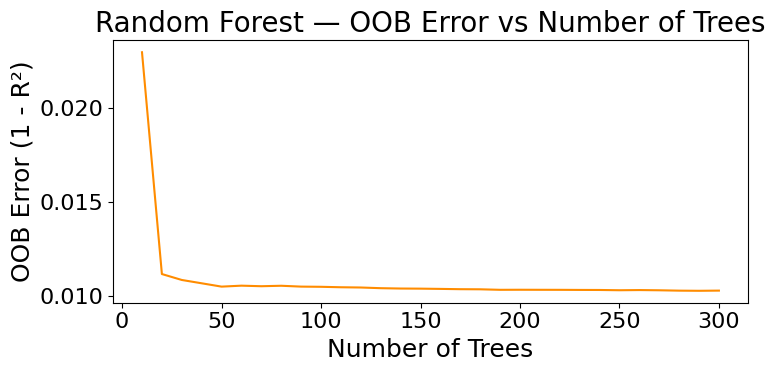

In [13]:
## RANDOM FOREST


rf = (
  RFModel("Random Forest", X_train, X_val, X_test, y_train, y_val, y_test)
  .tune(n_iter=20)
  .evaluate(on='val')
  .evaluate(on='test')
  .oob_score()
  .feature_importance()
  .residual_plot(on='test')
  .compare_splits()
  .plot_learning_curve()
)

✓ Publication figures saved: xgb_vs_rf_comparison.png & .pdf


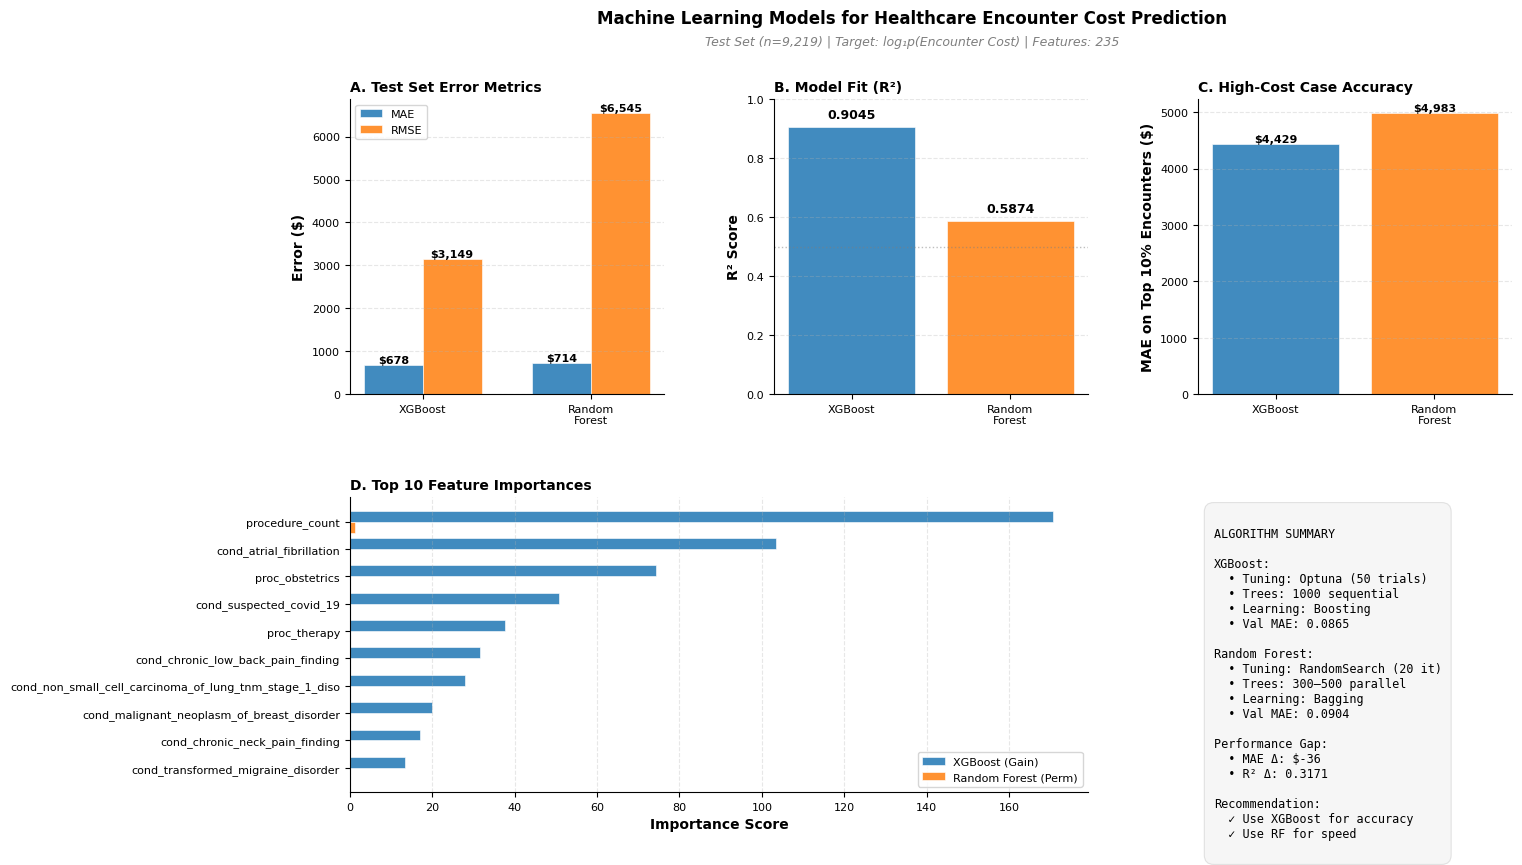

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.inspection import permutation_importance

# Set publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

# Colors
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GRAY = '#7f7f7f'

# Create figure with 2 rows, 3 columns
fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# ═════════════════════════════════════════════════════════════════════════════
# ROW 1: PERFORMANCE METRICS
# ═════════════════════════════════════════════════════════════════════════════

# PANEL A: Test Set Performance - MAE & RMSE in Dollars
ax_a = fig.add_subplot(gs[0, 0])

models = ['XGBoost', 'Random\nForest']
mae_vals = [xgb.results['test']['mae_dollars'], rf.results['test']['mae_dollars']]
rmse_vals = [xgb.results['test']['rmse_dollars'], rf.results['test']['rmse_dollars']]

x = np.arange(len(models))
width = 0.35

bars1 = ax_a.bar(x - width/2, mae_vals, width, label='MAE', color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.5)
bars2 = ax_a.bar(x + width/2, rmse_vals, width, label='RMSE', color=ORANGE, alpha=0.85, edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width()/2., height,
              f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width()/2., height,
              f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_a.set_ylabel('Error ($)', fontweight='bold')
ax_a.set_title('A. Test Set Error Metrics', fontweight='bold', loc='left', fontsize=10)
ax_a.set_xticks(x)
ax_a.set_xticklabels(models)
ax_a.legend(loc='upper left', fontsize=8)
ax_a.grid(axis='y', alpha=0.3, linestyle='--')
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# PANEL B: R² Score Comparison
ax_b = fig.add_subplot(gs[0, 1])

r2_vals = [xgb.results['test']['r2_dollars'], rf.results['test']['r2_dollars']]
bars = ax_b.bar(models, r2_vals, color=[BLUE, ORANGE], alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, r2_vals):
    ax_b.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
              f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_b.set_ylabel('R² Score', fontweight='bold')
ax_b.set_title('B. Model Fit (R²)', fontweight='bold', loc='left', fontsize=10)
ax_b.set_ylim(0, 1)
ax_b.axhline(0.5, color=GRAY, linestyle=':', linewidth=1, alpha=0.5, label='Baseline (0.5)')
ax_b.grid(axis='y', alpha=0.3, linestyle='--')
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# PANEL C: Top-10% Cost Encounters (High-Cost Cases)
ax_c = fig.add_subplot(gs[0, 2])

mae_p90 = [xgb.results['test']['mae_p90'], rf.results['test']['mae_p90']]
bars = ax_c.bar(models, mae_p90, color=[BLUE, ORANGE], alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, mae_p90):
    ax_c.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
              f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_c.set_ylabel('MAE on Top 10% Encounters ($)', fontweight='bold')
ax_c.set_title('C. High-Cost Case Accuracy', fontweight='bold', loc='left', fontsize=10)
ax_c.grid(axis='y', alpha=0.3, linestyle='--')
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ═════════════════════════════════════════════════════════════════════════════
# ROW 2: ALGORITHM CHARACTERISTICS & FEATURES
# ═════════════════════════════════════════════════════════════════════════════

# PANEL D: Top 10 Features
ax_d = fig.add_subplot(gs[1, 0:2])

# Get XGBoost feature importance
booster_xgb = xgb.best_model.get_booster()
booster_xgb.feature_names = list(xgb.X_train.columns)
xgb_imp = (
    pd.Series(booster_xgb.get_score(importance_type='gain'))
    .sort_values(ascending=False)
    .head(10)
)

# Get RF feature importance
perm_result = permutation_importance(rf.best_model, rf.X_val, rf.y_val, n_repeats=10, random_state=5003, n_jobs=-1)
rf_imp = (
    pd.Series(perm_result.importances_mean, index=rf.X_train.columns)
    .sort_values(ascending=False)
    .head(10)
)

# Plot side by side
y_pos = np.arange(10)
ax_d.barh(y_pos + 0.2, xgb_imp.values[::-1], 0.4, label='XGBoost (Gain)',
          color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.5)
ax_d.barh(y_pos - 0.2, rf_imp.values[::-1], 0.4, label='Random Forest (Perm)',
          color=ORANGE, alpha=0.85, edgecolor='white', linewidth=0.5)

ax_d.set_yticks(y_pos)
ax_d.set_yticklabels(xgb_imp.index[::-1], fontsize=8)
ax_d.set_xlabel('Importance Score', fontweight='bold')
ax_d.set_title('D. Top 10 Feature Importances', fontweight='bold', loc='left', fontsize=10)
ax_d.legend(loc='lower right', fontsize=8)
ax_d.grid(axis='x', alpha=0.3, linestyle='--')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# PANEL E: Summary Box
ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')

summary_text = f"""
ALGORITHM SUMMARY

XGBoost:
  • Tuning: Optuna (50 trials)
  • Trees: 1000 sequential
  • Learning: Boosting
  • Val MAE: {xgb.cv_mae:.4f}

Random Forest:
  • Tuning: RandomSearch (20 it)
  • Trees: 300–500 parallel
  • Learning: Bagging
  • Val MAE: {rf.cv_mae:.4f}

Performance Gap:
  • MAE Δ: ${mae_vals[0]-mae_vals[1]:,.0f}
  • R² Δ: {r2_vals[0]-r2_vals[1]:.4f}

Recommendation:
  ✓ Use XGBoost for accuracy
  ✓ Use RF for speed
"""

ax_e.text(0.05, 0.95, summary_text, transform=ax_e.transAxes,
          fontsize=8.5, verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgray',
                    alpha=0.2, edgecolor=GRAY, linewidth=0.8))

# Overall title
fig.suptitle('Machine Learning Models for Healthcare Encounter Cost Prediction',
             fontsize=12, fontweight='bold', y=0.98)

# Add subtitle
fig.text(0.5, 0.94, 'Test Set (n=9,219) | Target: log₁p(Encounter Cost) | Features: 235',
         ha='center', fontsize=9, style='italic', color=GRAY)

plt.savefig('xgb_vs_rf_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('xgb_vs_rf_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Publication figures saved: xgb_vs_rf_comparison.png & .pdf")
plt.show()

✓ Saved: xgb_vs_rf.png & .pdf


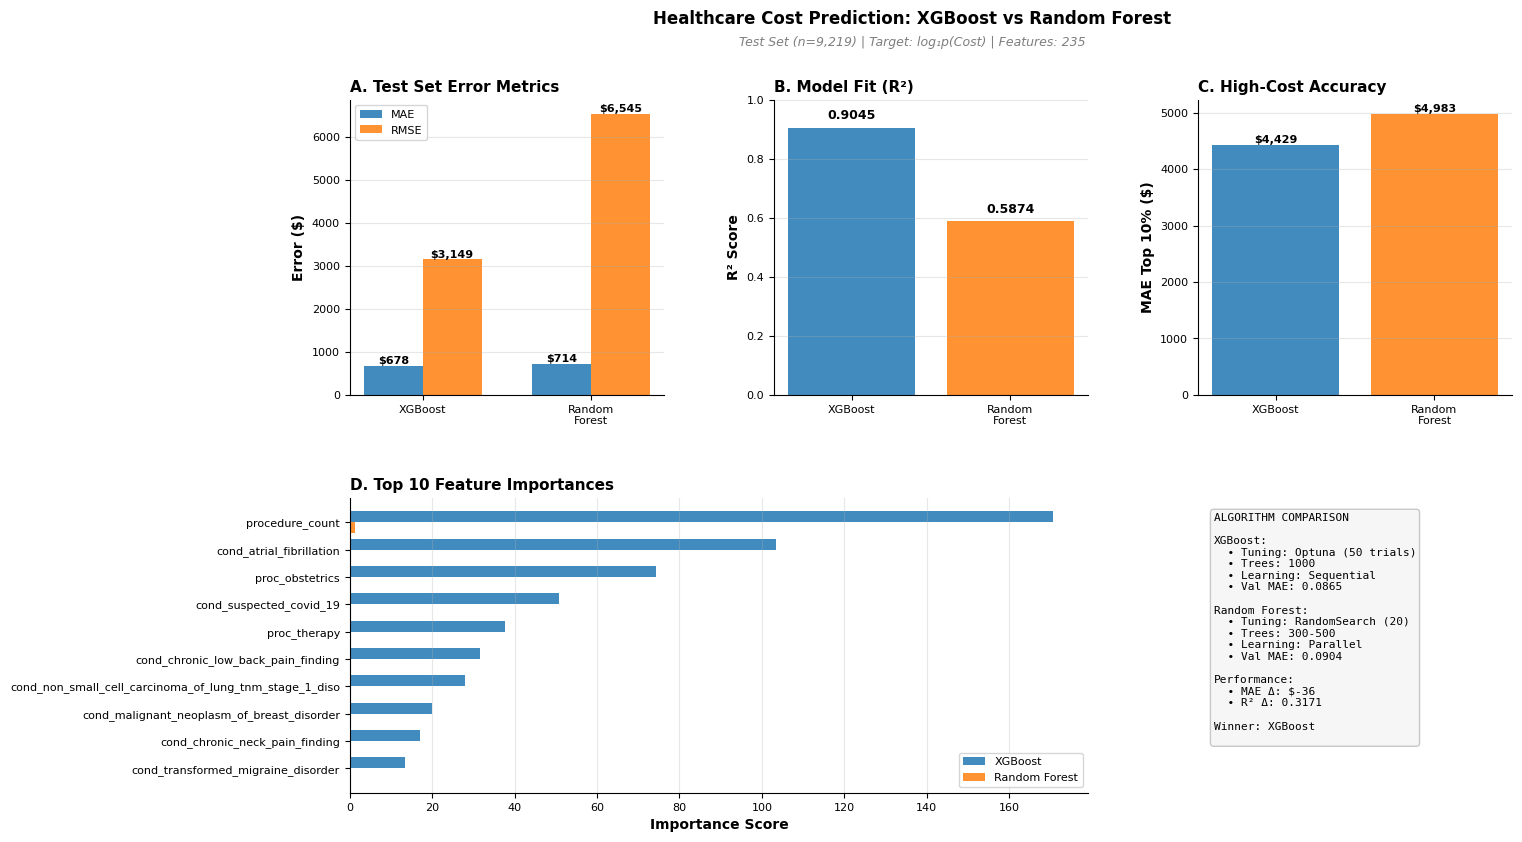

In [17]:
# ============================================================================
# PUBLICATION-WORTHY COMPARISON: XGBoost vs Random Forest
# Paste into notebook AFTER training xgb and rf models
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.inspection import permutation_importance

# Set publication-quality defaults
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
})

BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GRAY = '#7f7f7f'

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# PANEL A: MAE & RMSE
ax_a = fig.add_subplot(gs[0, 0])
models = ['XGBoost', 'Random\nForest']
mae_vals = [xgb.results['test']['mae_dollars'], rf.results['test']['mae_dollars']]
rmse_vals = [xgb.results['test']['rmse_dollars'], rf.results['test']['rmse_dollars']]

x = np.arange(len(models))
width = 0.35
bars1 = ax_a.bar(x - width/2, mae_vals, width, label='MAE', color=BLUE, alpha=0.85)
bars2 = ax_a.bar(x + width/2, rmse_vals, width, label='RMSE', color=ORANGE, alpha=0.85)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax_a.text(bar.get_x() + bar.get_width()/2., height,
              f'${height:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_a.set_ylabel('Error ($)', fontweight='bold')
ax_a.set_title('A. Test Set Error Metrics', fontweight='bold', loc='left')
ax_a.set_xticks(x)
ax_a.set_xticklabels(models)
ax_a.legend(fontsize=8)
ax_a.grid(axis='y', alpha=0.3)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# PANEL B: R²
ax_b = fig.add_subplot(gs[0, 1])
r2_vals = [xgb.results['test']['r2_dollars'], rf.results['test']['r2_dollars']]
bars = ax_b.bar(models, r2_vals, color=[BLUE, ORANGE], alpha=0.85)

for bar, val in zip(bars, r2_vals):
    ax_b.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
              f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax_b.set_ylabel('R² Score', fontweight='bold')
ax_b.set_title('B. Model Fit (R²)', fontweight='bold', loc='left')
ax_b.set_ylim(0, 1)
ax_b.grid(axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# PANEL C: High-cost accuracy
ax_c = fig.add_subplot(gs[0, 2])
mae_p90 = [xgb.results['test']['mae_p90'], rf.results['test']['mae_p90']]
bars = ax_c.bar(models, mae_p90, color=[BLUE, ORANGE], alpha=0.85)

for bar, val in zip(bars, mae_p90):
    ax_c.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
              f'${val:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_c.set_ylabel('MAE Top 10% ($)', fontweight='bold')
ax_c.set_title('C. High-Cost Accuracy', fontweight='bold', loc='left')
ax_c.grid(axis='y', alpha=0.3)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# PANEL D: Feature importance
ax_d = fig.add_subplot(gs[1, 0:2])

# XGBoost features
booster = xgb.best_model.get_booster()
booster.feature_names = list(xgb.X_train.columns)
xgb_imp = pd.Series(booster.get_score(importance_type='gain')).sort_values(ascending=False).head(10)

# RF features
perm_result = permutation_importance(rf.best_model, rf.X_val, rf.y_val, n_repeats=5, random_state=5003, n_jobs=-1)
rf_imp = pd.Series(perm_result.importances_mean, index=rf.X_train.columns).sort_values(ascending=False).head(10)

y_pos = np.arange(10)
ax_d.barh(y_pos + 0.2, xgb_imp.values[::-1], 0.4, label='XGBoost', color=BLUE, alpha=0.85)
ax_d.barh(y_pos - 0.2, rf_imp.values[::-1], 0.4, label='Random Forest', color=ORANGE, alpha=0.85)
ax_d.set_yticks(y_pos)
ax_d.set_yticklabels(xgb_imp.index[::-1], fontsize=8)
ax_d.set_xlabel('Importance Score', fontweight='bold')
ax_d.set_title('D. Top 10 Feature Importances', fontweight='bold', loc='left')
ax_d.legend(fontsize=8, loc='lower right')
ax_d.grid(axis='x', alpha=0.3)
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

# PANEL E: Summary
ax_e = fig.add_subplot(gs[1, 2])
ax_e.axis('off')

summary = f"""ALGORITHM COMPARISON

XGBoost:
  • Tuning: Optuna (50 trials)
  • Trees: 1000
  • Learning: Sequential
  • Val MAE: {xgb.cv_mae:.4f}

Random Forest:
  • Tuning: RandomSearch (20)
  • Trees: 300-500
  • Learning: Parallel
  • Val MAE: {rf.cv_mae:.4f}

Performance:
  • MAE Δ: ${mae_vals[0]-mae_vals[1]:,.0f}
  • R² Δ: {r2_vals[0]-r2_vals[1]:.4f}

Winner: XGBoost
"""

ax_e.text(0.05, 0.95, summary, transform=ax_e.transAxes, fontsize=8,
          verticalalignment='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.2))

fig.suptitle('Healthcare Cost Prediction: XGBoost vs Random Forest',
             fontsize=12, fontweight='bold', y=0.98)
fig.text(0.5, 0.94, 'Test Set (n=9,219) | Target: log₁p(Cost) | Features: 235',
         ha='center', fontsize=9, style='italic', color=GRAY)

plt.savefig('xgb_vs_rf.png', dpi=300, bbox_inches='tight')
plt.savefig('xgb_vs_rf.pdf', dpi=300, bbox_inches='tight')
print("✓ Saved: xgb_vs_rf.png & .pdf")
plt.show()

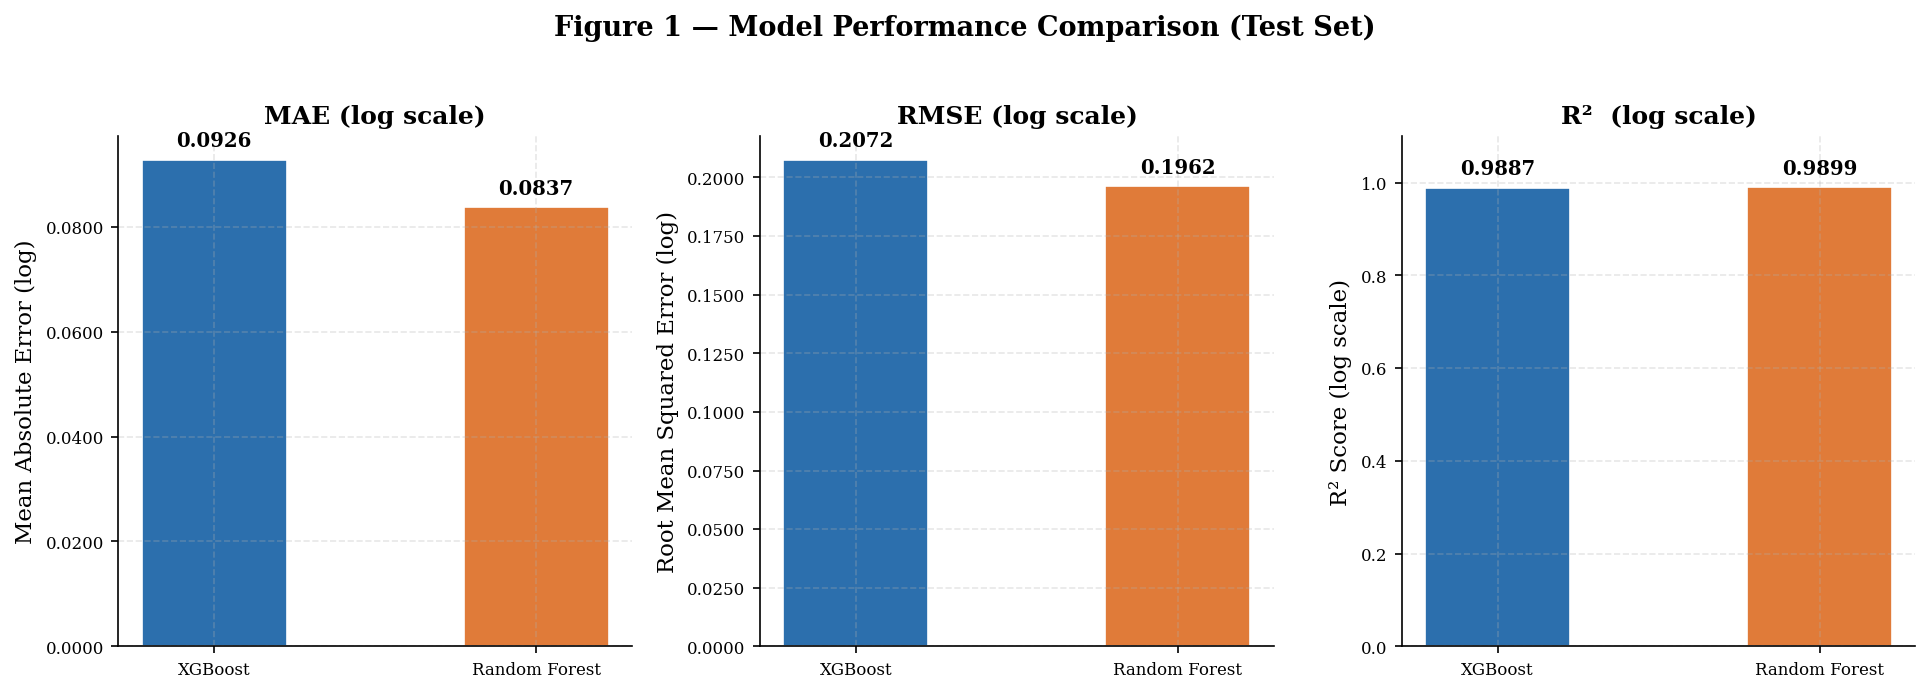

Saved: fig1_model_comparison.png


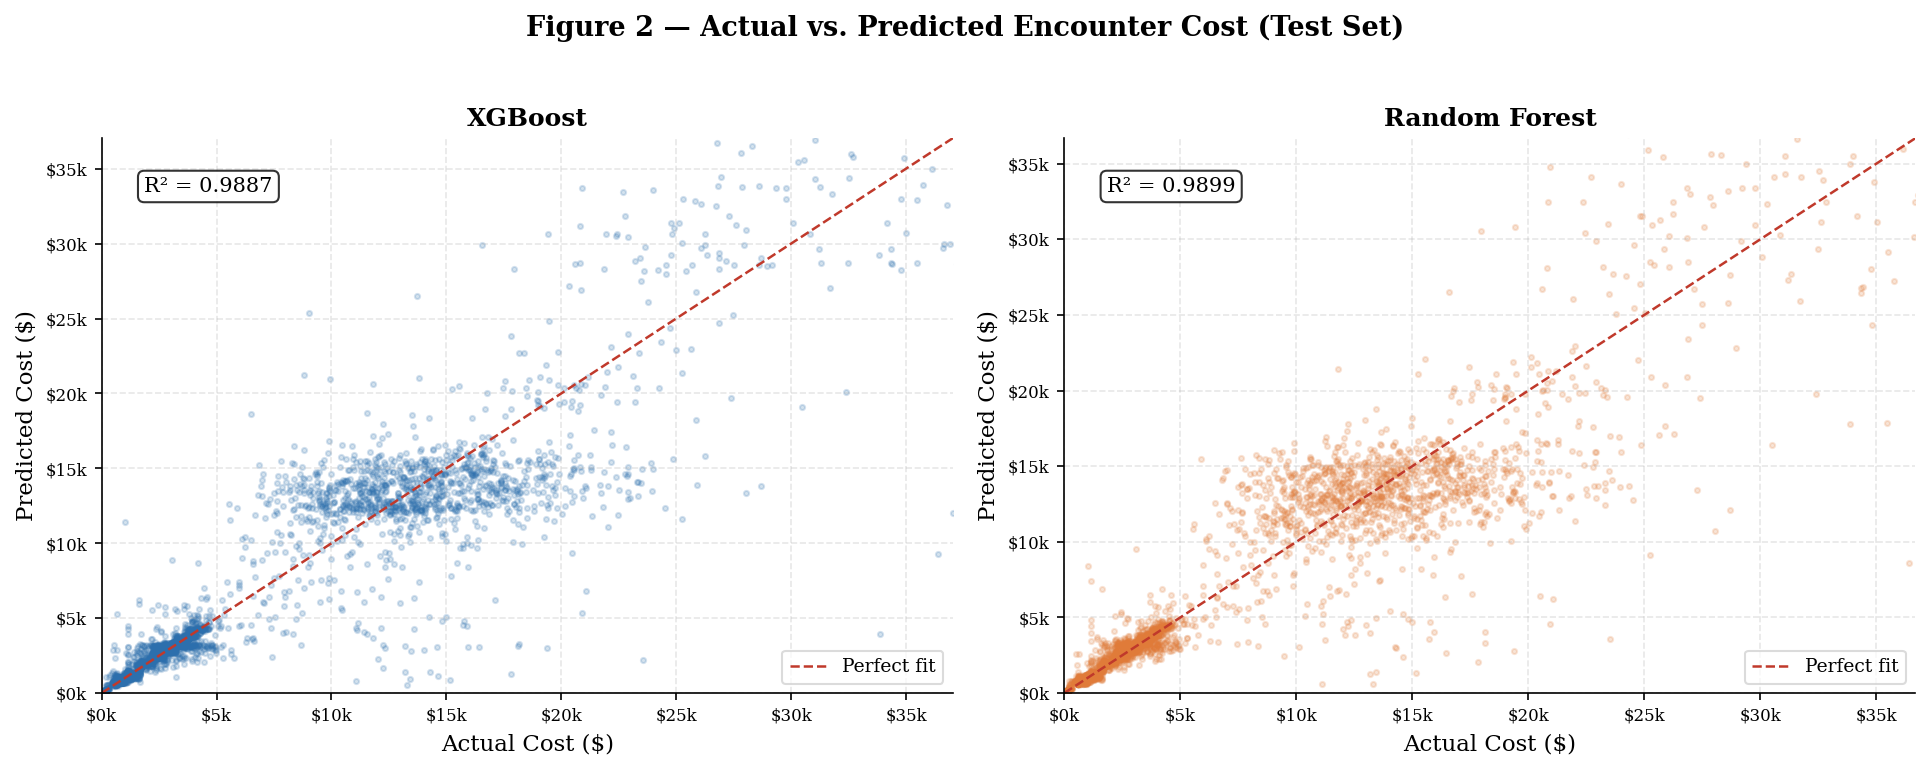

Saved: fig2_actual_vs_predicted.png


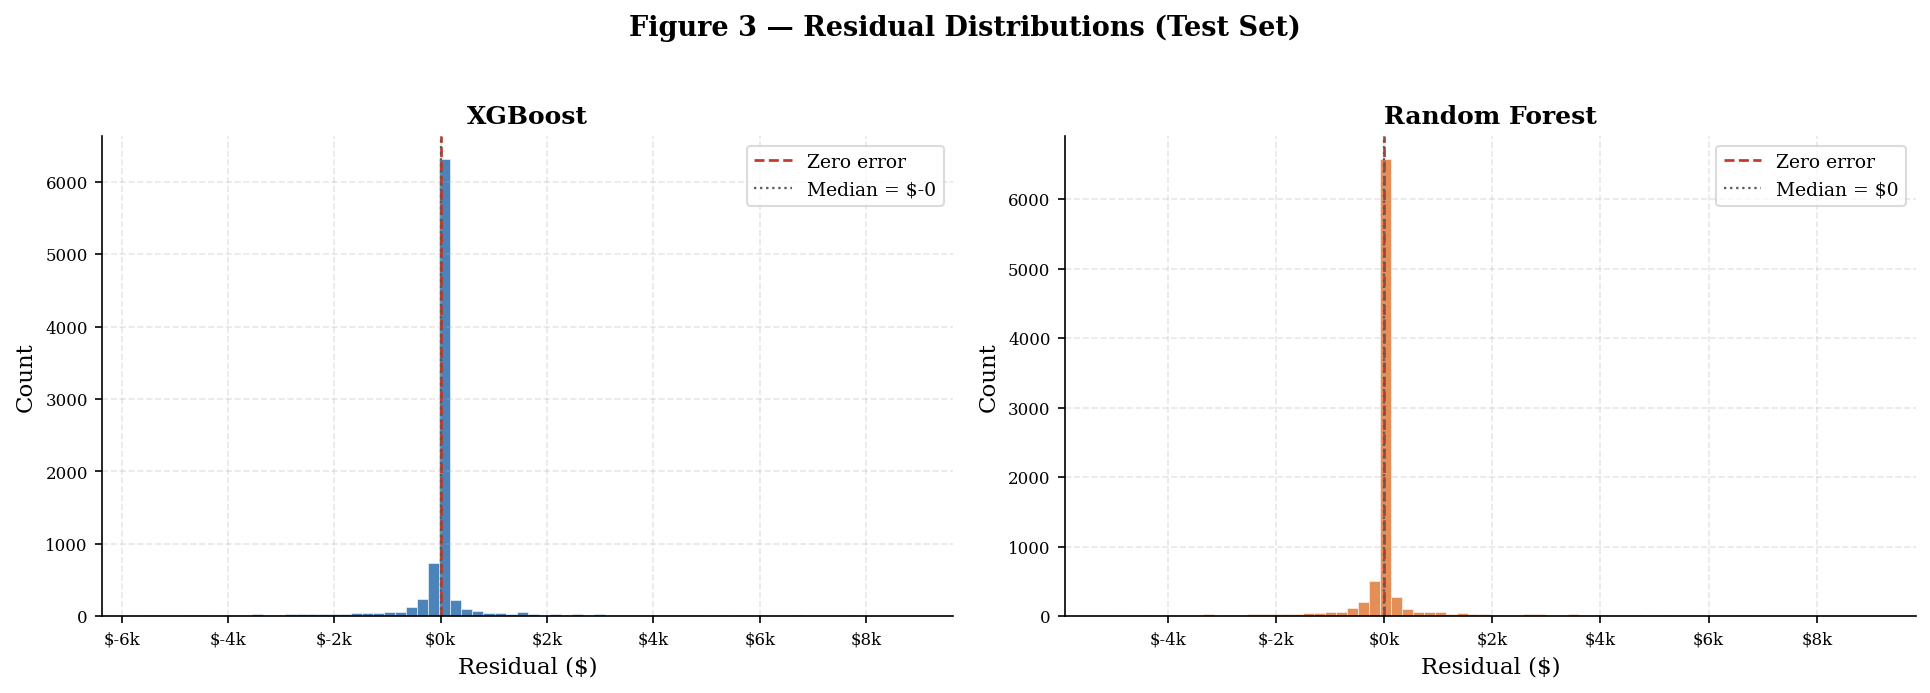

Saved: fig3_residual_distributions.png


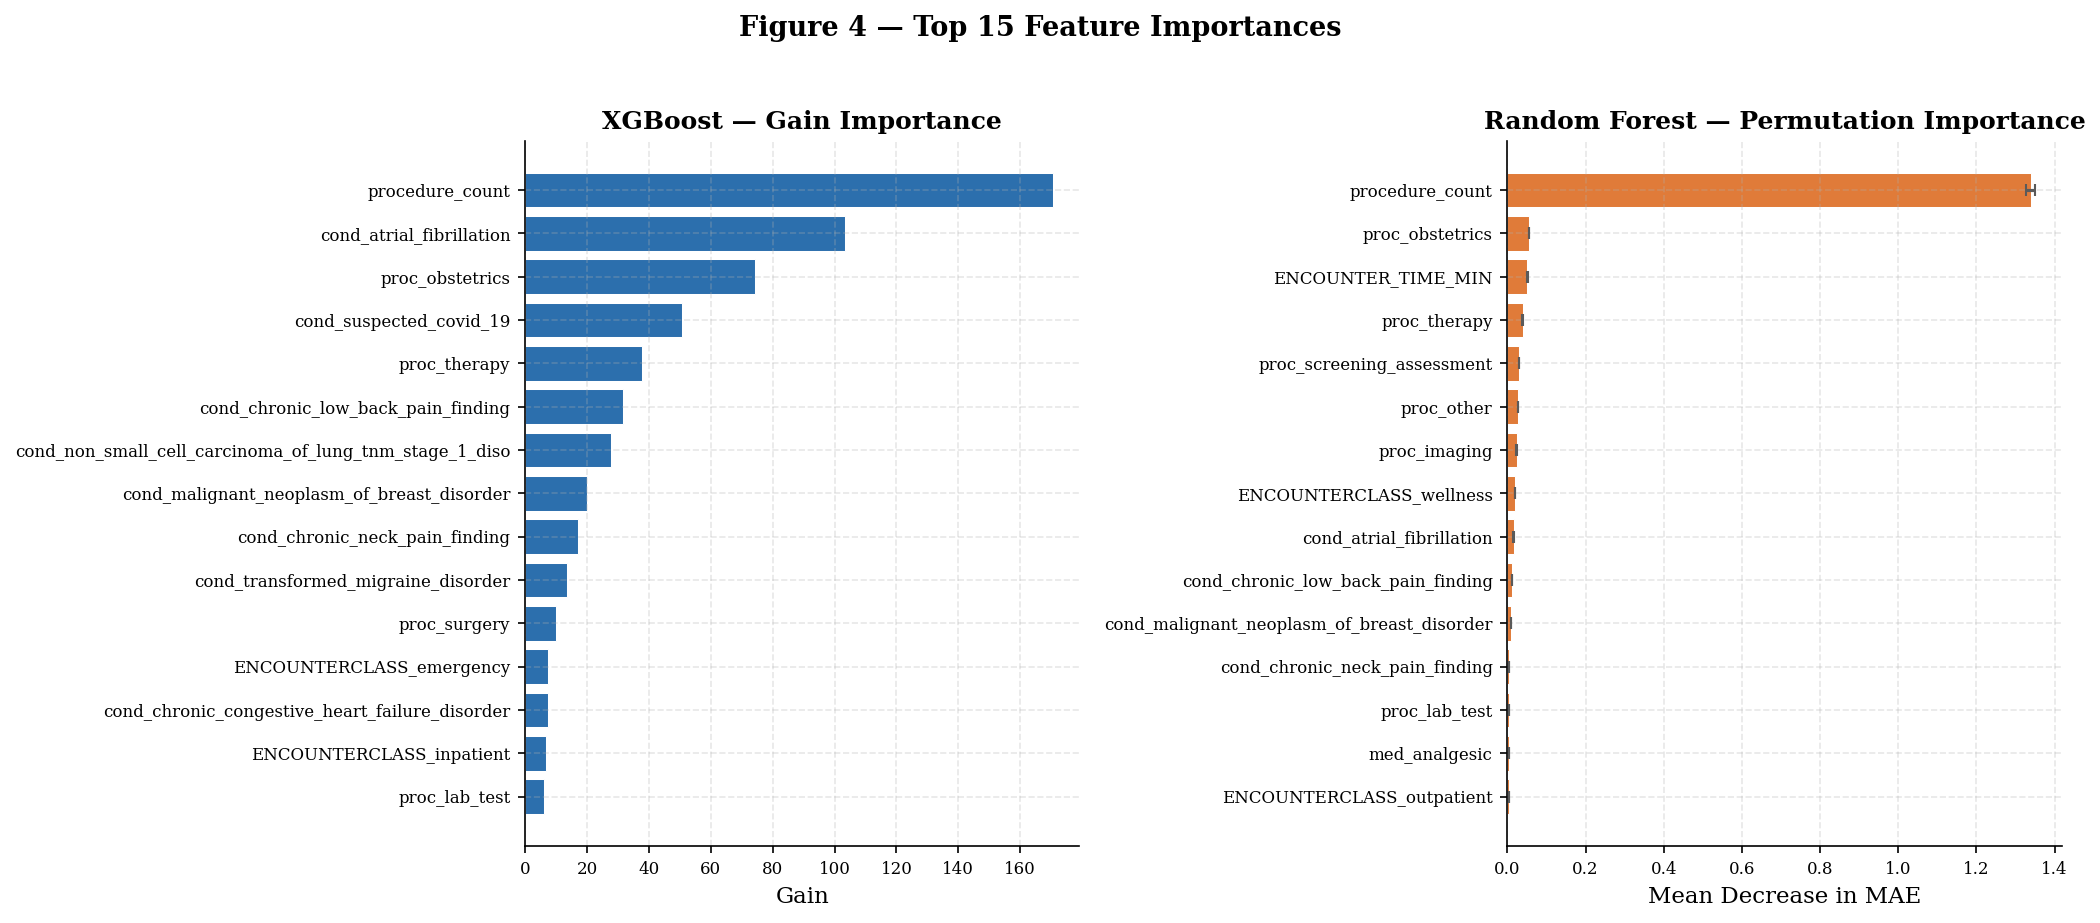

Saved: fig4_feature_importances.png


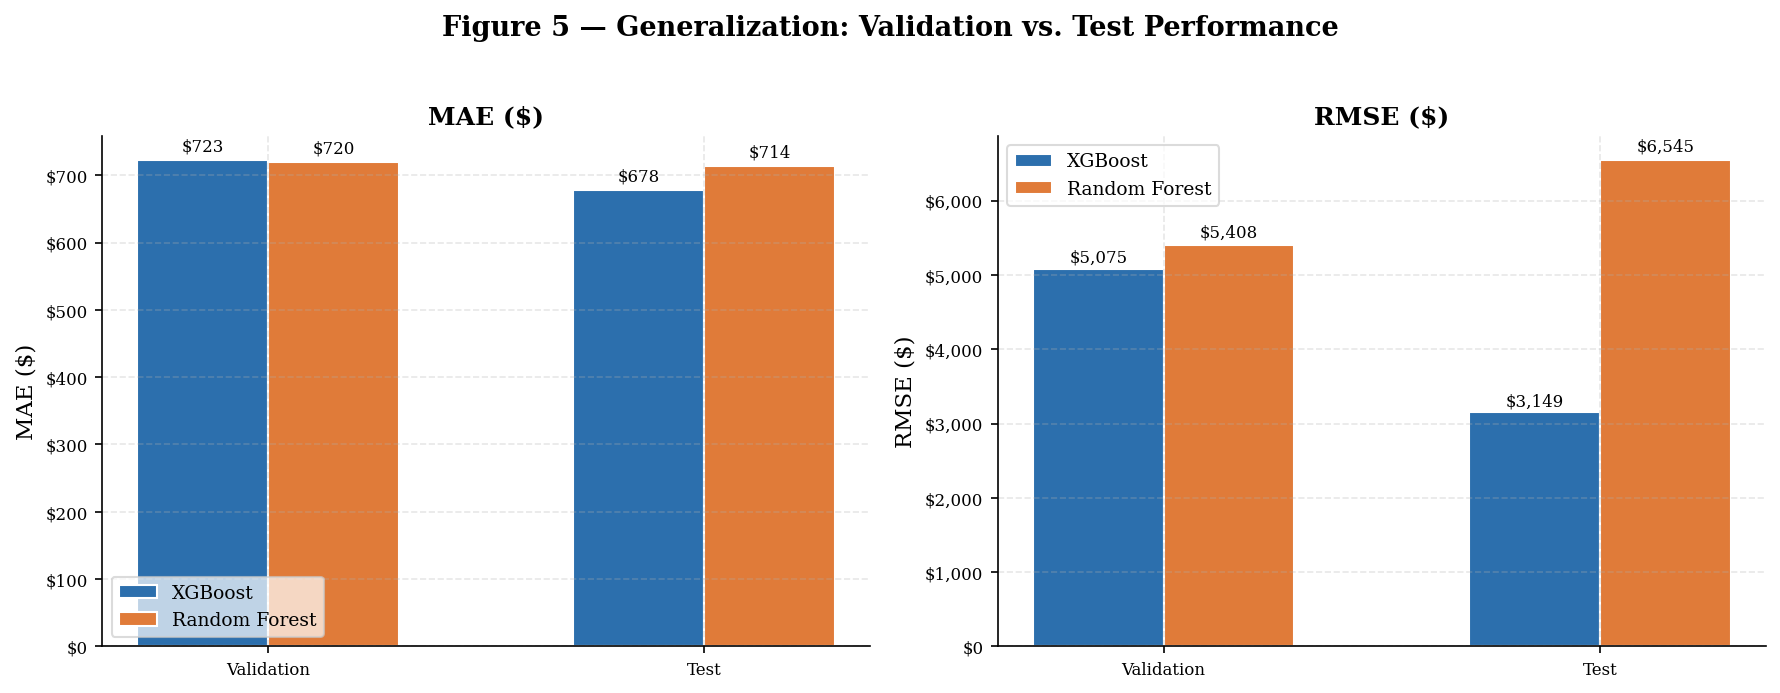

Saved: fig5_val_vs_test.png

✅ All 5 paper figures saved.


In [22]:
# ============================================================
# PAPER FIGURES — Publication-Quality Visualizations
# NOTE: Run the XGBoost (cell 17) and Random Forest (cell 18)
# training cells before running this cell.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance as perm_imp

# ── Guard: make sure models are trained ──────────────────
for _varname in ["xgb", "rf"]:
    assert _varname in dir(), f"'{_varname}' not found — run training cells first."
for _model, _splits in [(xgb, ["val", "test"]), (rf, ["val", "test"])]:
    for _s in _splits:
        assert _s in _model.results, (
            f"{_model.name} has no '{_s}' results — call .evaluate(on='{_s}') first."
        )

# ── Global style ─────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "legend.framealpha": 0.7,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

BLUE   = "#2c6fad"
ORANGE = "#e07b39"
GRAY   = "#5a5a5a"
RED    = "#c0392b"

# ── Helper: get dollar-scale predictions ─────────────────
def get_preds(model_obj, on="test"):
    is_xgb = hasattr(model_obj, "_imputer")
    if on == "val":
        X = model_obj._impute(model_obj.X_val) if is_xgb else model_obj.X_val
        y = model_obj.y_val
    else:
        X = model_obj._impute(model_obj.X_test) if is_xgb else model_obj.X_test
        y = model_obj.y_test
    y_pred_log     = model_obj.best_model.predict(X)
    y_true_dollars = np.expm1(y.values if hasattr(y, "values") else y)
    y_pred_dollars = np.expm1(y_pred_log)
    residuals      = y_true_dollars - y_pred_dollars
    return y_true_dollars, y_pred_dollars, residuals


# ╔══════════════════════════════════════════════════════════╗
# ║  FIGURE 1 — Model Performance Summary (Bar Chart)       ║
# ╚══════════════════════════════════════════════════════════╝
fig1, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig1.suptitle("Figure 1 — Model Performance Comparison (Test Set)",
              fontsize=13, fontweight="bold", y=1.02)

model_names  = ["XGBoost", "Random Forest"]
bar_colors   = [BLUE, ORANGE]
model_objs   = [xgb, rf]

# Build log-scale metric values (rmse_log computed inline since not stored)
def get_log_metrics(model_obj):
    mae  = model_obj.results["test"]["mae_log"]
    r2   = model_obj.results["test"]["r2_log"]
    is_xgb = hasattr(model_obj, "_imputer")
    X = model_obj._impute(model_obj.X_test) if is_xgb else model_obj.X_test
    y = model_obj.y_test
    y_pred_log = model_obj.best_model.predict(X)
    from sklearn.metrics import mean_squared_error as _mse
    rmse = np.sqrt(_mse(y.values if hasattr(y, "values") else y, y_pred_log))
    return mae, rmse, r2

log_metrics = [get_log_metrics(m) for m in model_objs]
metric_sets   = list(zip(*log_metrics))  # [[xgb_mae, rf_mae], [xgb_rmse, rf_rmse], [xgb_r2, rf_r2]]
metric_labels  = ["MAE (log scale)", "RMSE (log scale)", "R²  (log scale)"]
y_axis_labels  = ["Mean Absolute Error (log)", "Root Mean Squared Error (log)", "R² Score (log scale)"]
is_r2          = [False, False, True]

for ax, vals, label, ylabel, r2flag in zip(axes, metric_sets, metric_labels, y_axis_labels, is_r2):
    bars = ax.bar(model_names, vals, color=bar_colors,
                  width=0.45, edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, vals):
        fmt = f"{val:.4f}"
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02, fmt,
                ha="center", va="bottom", fontsize=9.5, fontweight="bold")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(ylabel)
    if r2flag:
        ax.set_ylim(0, 1.1)
    else:
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:.4f}")
        )

plt.tight_layout()
plt.savefig("fig1_model_comparison.png")
plt.show()
print("Saved: fig1_model_comparison.png")


# ╔══════════════════════════════════════════════════════════╗
# ║  FIGURE 2 — Actual vs Predicted (Both Models, Test Set) ║
# ╚══════════════════════════════════════════════════════════╝
fig2, axes = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("Figure 2 — Actual vs. Predicted Encounter Cost (Test Set)",
              fontsize=13, fontweight="bold", y=1.02)

for ax, model_obj, color, name in zip(axes, model_objs, bar_colors, model_names):
    y_true, y_pred, _ = get_preds(model_obj, on="test")
    ax.scatter(y_true, y_pred, alpha=0.20, s=6, color=color, rasterized=True)
    cap = np.percentile(np.concatenate([y_true, y_pred]), 99) * 1.05
    lim = [0, cap]
    ax.plot(lim, lim, color=RED, linewidth=1.2, linestyle="--", label="Perfect fit")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual Cost ($)")
    ax.set_ylabel("Predicted Cost ($)")
    ax.set_title(name, fontweight="bold")
    r2 = model_obj.results["test"]["r2_log"]
    ax.text(0.05, 0.93, f"R² = {r2:.4f}", transform=ax.transAxes,
            fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig2_actual_vs_predicted.png")
plt.show()
print("Saved: fig2_actual_vs_predicted.png")


# ╔══════════════════════════════════════════════════════════╗
# ║  FIGURE 3 — Residual Distributions Side-by-Side         ║
# ╚══════════════════════════════════════════════════════════╝
fig3, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig3.suptitle("Figure 3 — Residual Distributions (Test Set)",
              fontsize=13, fontweight="bold", y=1.02)

for ax, model_obj, color, name in zip(axes, model_objs, bar_colors, model_names):
    _, _, residuals = get_preds(model_obj, on="test")
    res_lo, res_hi = np.percentile(residuals, [1, 99])
    residuals_clipped = residuals[(residuals >= res_lo) & (residuals <= res_hi)]
    ax.hist(residuals_clipped, bins=70, color=color, edgecolor="white",
            linewidth=0.3, alpha=0.85)
    ax.axvline(0, color=RED, linewidth=1.3, linestyle="--", label="Zero error")
    ax.axvline(np.median(residuals), color=GRAY, linewidth=1.1,
               linestyle=":", label=f"Median = ${np.median(residuals):,.0f}")
    ax.set_xlabel("Residual ($)")
    ax.set_ylabel("Count")
    ax.set_title(name, fontweight="bold")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig3_residual_distributions.png")
plt.show()
print("Saved: fig3_residual_distributions.png")


# ╔══════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — Top 15 Feature Importances Side-by-Side     ║
# ╚══════════════════════════════════════════════════════════╝
fig4, axes = plt.subplots(1, 2, figsize=(14, 6))
fig4.suptitle("Figure 4 — Top 15 Feature Importances",
              fontsize=13, fontweight="bold", y=1.02)

# XGBoost: gain-based importance
booster = xgb.best_model.get_booster()
booster.feature_names = list(xgb.X_train.columns)
xgb_imp = (
    pd.Series(booster.get_score(importance_type="gain"))
    .sort_values(ascending=False)
    .head(15)
)
axes[0].barh(xgb_imp.index[::-1], xgb_imp.values[::-1],
             color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Gain")
axes[0].set_title("XGBoost — Gain Importance", fontweight="bold")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}")
)

# Random Forest: permutation importance
perm = perm_imp(rf.best_model, rf.X_val, rf.y_val,
                n_repeats=10, random_state=5003, n_jobs=-1)
rf_imp = (
    pd.Series(perm.importances_mean, index=rf.X_train.columns)
    .sort_values(ascending=False)
    .head(15)
)
rf_err = pd.Series(perm.importances_std, index=rf.X_train.columns).loc[rf_imp.index]
axes[1].barh(rf_imp.index[::-1], rf_imp.values[::-1],
             xerr=rf_err.values[::-1], color=ORANGE,
             ecolor=GRAY, capsize=3, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Mean Decrease in MAE")
axes[1].set_title("Random Forest — Permutation Importance", fontweight="bold")

plt.tight_layout()
plt.savefig("fig4_feature_importances.png")
plt.show()
print("Saved: fig4_feature_importances.png")


# ╔══════════════════════════════════════════════════════════╗
# ║  FIGURE 5 — Val vs Test Generalization                  ║
# ╚══════════════════════════════════════════════════════════╝
fig5, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig5.suptitle("Figure 5 — Generalization: Validation vs. Test Performance",
              fontsize=13, fontweight="bold", y=1.02)

metrics = ["mae_dollars", "rmse_dollars"]
mlabels = ["MAE ($)", "RMSE ($)"]
x = np.arange(2)  # [Validation, Test]
width = 0.3

for ax, metric, mlabel in zip(axes, metrics, mlabels):
    for i, (model_obj, color, name) in enumerate(zip(model_objs, bar_colors, model_names)):
        vals = [model_obj.results["val"][metric], model_obj.results["test"][metric]]
        bars = ax.bar(x + i * width, vals, width, label=name,
                      color=color, edgecolor="white")
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01, f"${v:,.0f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(["Validation", "Test"])
    ax.set_title(mlabel, fontweight="bold")
    ax.set_ylabel(mlabel)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig5_val_vs_test.png")
plt.show()
print("Saved: fig5_val_vs_test.png")

print("\n✅ All 5 paper figures saved.")
